# PHQ-8 Depression Detection for Anomaly Detection
## Mid Fusion: Mental-RoBERTa + WavLM

This notebook trains a **mid-fusion classifier** for PHQ-8 depression detection by combining text embeddings from the Mental-RoBERTa branch with audio embeddings from the WavLM branch.

## Core idea
Each modality is encoded separately using a pre-trained LSTM + attention model. The resulting text and audio embeddings are concatenated and passed to a new trainable MLP classifier.

```text
text chunks (768-dim)  -> frozen text encoder  ->  64-dim text embedding  --+
                                                                        concat -> trainable MLP -> logit
audio chunks (768-dim) -> frozen audio encoder -> 128-dim audio embedding --+
```

## What this notebook does
1. Installs dependencies and imports the required libraries.
2. Loads labels for train, dev, and test splits.
3. Loads pre-extracted text and audio feature caches.
4. Rebuilds the single-modality encoders used during earlier experiments.
5. Loads their best checkpoints and freezes the encoder weights.
6. Pre-computes one embedding per participant per modality.
7. Trains a fusion MLP on top of those embeddings.
8. Tunes hyperparameters with Optuna.
9. Evaluates the final model on the test set.

## Important assumptions
- Feature caches already exist in `processed/`.
- Best encoder checkpoints already exist in `experiments/best_model/`.
- Only the fusion MLP is trained in this notebook; the text and audio encoders remain frozen.

## EDA handling
For training only, each EDA-augmented text sample is treated as a virtual participant. Its text embedding comes from the augmented text features, while its audio embedding is copied from the corresponding real participant.


## 1. Install Dependencies

Run this cell once per environment if the required Python packages are not already installed.


In [35]:
# Install the packages used throughout this notebook.
# It is safe to rerun this cell if they are already installed.
!pip install transformers tqdm pandas numpy scikit-learn matplotlib optuna --quiet
print("All packages ready.")

All packages ready.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports and Configuration

This section imports the libraries used in the experiment, sets reproducibility controls, and defines all dataset, cache, checkpoint, and output paths.


In [36]:
# Standard library imports.
import os
import random

# Data utilities and filesystem helpers.
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

# PyTorch modules for model definition and optimization.
import torch
import torch.nn as nn
from torch.optim import Adam

# Plotting and evaluation helpers.
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report
)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Imports successful.")

Imports successful.


In [37]:
# --- Reproducibility ---
# Fix random seeds so repeated runs are easier to compare.
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- Paths ---
# These paths assume the notebook is executed from the `experiments/` directory.
BASE_DIR      = Path("..")
DATASET_DIR   = BASE_DIR / "dataset"
PROCESSED_DIR = BASE_DIR / "processed"

TRAIN_CSV = DATASET_DIR / "train_split_Depression_AVEC2017.csv"
DEV_CSV   = DATASET_DIR / "dev_split_Depression_AVEC2017.csv"
TEST_CSV  = DATASET_DIR / "full_test_split.csv"

# Feature caches produced earlier in the pipeline.
TEXT_FEATURE_CACHE     = PROCESSED_DIR / "mental_roberta_features_cls.npz"
EDA_TEXT_FEATURE_CACHE = PROCESSED_DIR / "mental_roberta_features_eda_cls.npz"
AUDIO_FEATURE_CACHE    = PROCESSED_DIR / "wavlm_features_cls.npz"

# Best single-modality checkpoints used to initialize the frozen encoders.
TEXT_CKPT  = BASE_DIR / "experiments" / "best_model" / "mental_roberta_lstm_cls" / "mental_roberta_lstm_cls_best.pth"
AUDIO_CKPT = BASE_DIR / "experiments" / "best_model" / "wavlm_mlp_lstm_cls" / "wavLM_MLP_LSTM_cls_best.pth"

# Directory for saving fusion checkpoints and outputs.
SAVE_DIR = BASE_DIR / "experiments" / "best_model" / "mid_fusion_mentalroberta_wavlm"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Use GPU if available; otherwise fall back to CPU.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Seed: {SEED}  |  Device: {DEVICE}")
print(f"Text ckpt  : {TEXT_CKPT.resolve()}")
print(f"Audio ckpt : {AUDIO_CKPT.resolve()}")

Seed: 42  |  Device: cuda
Text ckpt  : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\experiments\best_model\mental_roberta_lstm_cls\mental_roberta_lstm_cls_best.pth
Audio ckpt : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\experiments\best_model\wavlm_mlp_lstm_cls\wavLM_MLP_LSTM_cls_best.pth


## 3. Load Label Files

Load the binary PHQ-8 labels for each split and build simple participant-to-label lookup tables.


In [38]:
# Load the binary labels for each split.
# The test CSV uses a slightly different column name, so it is renamed for consistency.
train_df = pd.read_csv(TRAIN_CSV)[["Participant_ID", "PHQ8_Binary"]]
dev_df   = pd.read_csv(DEV_CSV)[["Participant_ID", "PHQ8_Binary"]]
test_df  = pd.read_csv(TEST_CSV)[["Participant_ID", "PHQ_Binary"]].rename(
    columns={"PHQ_Binary": "PHQ8_Binary"}
)

# Convert each split into a dictionary: participant ID -> binary label.
train_labels = dict(zip(train_df.Participant_ID, train_df.PHQ8_Binary))
dev_labels   = dict(zip(dev_df.Participant_ID,   dev_df.PHQ8_Binary))
test_labels  = dict(zip(test_df.Participant_ID,  test_df.PHQ8_Binary))
pid_to_split = (
    {pid: "train" for pid in train_labels}
    | {pid: "dev"   for pid in dev_labels}
    | {pid: "test"  for pid in test_labels}
)

# Quick class-distribution summary for sanity checking.
for name, labels in [("Train", train_labels), ("Dev", dev_labels), ("Test", test_labels)]:
    dep = sum(labels.values())
    print(f"{name:5s}: {len(labels):3d} participants  depressed: {dep}  control: {len(labels)-dep}")

Train: 107 participants  depressed: 30  control: 77
Dev  :  35 participants  depressed: 12  control: 23
Test :  47 participants  depressed: 14  control: 33


## 4. Load Pre-extracted Features

Load the cached chunk-level features for text and audio, group them by participant, and optionally inject EDA text features into the training split.


In [39]:
def load_participant_features(cache_path: Path, label: str, eda_cache_path: Path = None):
    """
    Load a feature cache and group chunk-level features into participant-level records.

    Returns a dictionary with three split keys (`train`, `dev`, `test`), where each
    value is a list of `(pid, {feats, label})` pairs.
    """
    assert cache_path.exists(), f"Cache not found: {cache_path}"
    print(f"Loading {label} from {cache_path.name} ...")
    cache = np.load(cache_path, allow_pickle=False)
    in_memory = {
        "train": defaultdict(lambda: {"feats": [], "label": None}),
        "dev":   defaultdict(lambda: {"feats": [], "label": None}),
        "test":  defaultdict(lambda: {"feats": [], "label": None}),
    }

    # Group all chunk-level features by participant within each split.
    for feat, lbl, pid, split_b in zip(
        cache["feats"], cache["binary_labels"], cache["pids"], cache["splits"]
    ):
        s = split_b.decode(); pid = int(pid)
        in_memory[s][pid]["feats"].append(feat)
        in_memory[s][pid]["label"] = int(lbl)

    # If EDA text features are provided, treat each augmentation as a virtual participant.
    if eda_cache_path is not None and eda_cache_path.exists():
        print(f"  + EDA features from {eda_cache_path.name}")
        eda = np.load(eda_cache_path, allow_pickle=False)
        eda_virtual = defaultdict(lambda: {"feats": [], "label": None})
        for feat, lbl, pid, aug_i in zip(
            eda["feats"], eda["binary_labels"], eda["pids"], eda["aug_indices"]
        ):
            vpid = int(pid) * 1000 + int(aug_i)
            eda_virtual[vpid]["feats"].append(feat)
            eda_virtual[vpid]["label"] = int(lbl)
        for vpid, data in eda_virtual.items():
            in_memory["train"][vpid] = data
        n_dep = sum(d["label"] for d in eda_virtual.values())
        print(f"  Added {len(eda_virtual)} EDA virtual participants "
              f"(dep: {n_dep}  ctrl: {len(eda_virtual)-n_dep})")

    splits_list = {s: list(in_memory[s].items()) for s in ("train", "dev", "test")}
    for s, name in [("train", "train"), ("dev", "val"), ("test", "test")]:
        n_p = len(splits_list[s])
        n_d = sum(d["label"] for _, d in splits_list[s])
        print(f"  {name:5s}: {n_p} participants  dep: {n_d}  ctrl: {n_p-n_d}")
    return splits_list


# Text split includes optional EDA augmentation. Audio split uses real participants only.
text_splits  = load_participant_features(TEXT_FEATURE_CACHE, "text", EDA_TEXT_FEATURE_CACHE)
print()
audio_splits = load_participant_features(AUDIO_FEATURE_CACHE, "audio")

Loading text from mental_roberta_features_cls.npz ...
  + EDA features from mental_roberta_features_eda_cls.npz
  Added 107 EDA virtual participants (dep: 30  ctrl: 77)
  train: 214 participants  dep: 60  ctrl: 154
  val  : 35 participants  dep: 12  ctrl: 23
  test : 47 participants  dep: 14  ctrl: 33

Loading audio from wavlm_features_cls.npz ...
  train: 107 participants  dep: 30  ctrl: 77
  val  : 35 participants  dep: 12  ctrl: 23
  test : 47 participants  dep: 14  ctrl: 33


## 5. Model Architectures

Both encoder classes expose `get_embedding(x)`, which returns the attention-pooled and LayerNorm-normalized representation before the original classifier head.
The `forward` method is kept for checkpoint compatibility, but the fusion notebook only uses `get_embedding`.


In [40]:
# Rebuild the text encoder architecture used in the single-modality Mental-RoBERTa experiment.
# This definition must match the saved checkpoint so the weights can be loaded correctly.
# ── Text encoder (Mental-RoBERTa LSTM) ────────────────────────────────────────
class MentalRoBERTaLSTMEncoder(nn.Module):
    def __init__(self, input_dim=768, lstm_hidden=64, lstm_layers=1,
                 bidirectional=False, hidden_dim=64, dropout=0.6):
        super().__init__()
        self.lstm_out_dim = lstm_hidden * (2 if bidirectional else 1)
        self.lstm = nn.LSTM(input_dim, lstm_hidden, lstm_layers,
                            batch_first=True, bidirectional=bidirectional,
                            dropout=dropout if lstm_layers > 1 else 0.0)
        self.attention     = nn.Linear(self.lstm_out_dim, 1)
        self.norm          = nn.LayerNorm(self.lstm_out_dim)
        self.input_dropout = nn.Dropout(dropout)
        self.classifier    = nn.Sequential(
            nn.Linear(self.lstm_out_dim, hidden_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(hidden_dim, 1),
        )

    def get_embedding(self, x: torch.Tensor) -> torch.Tensor:
        """Returns the 64-dim attention-pooled embedding (LayerNorm applied)."""
        enc, _ = self.lstm(self.input_dropout(x).unsqueeze(0))
        enc    = enc.squeeze(0)
        attn_w = torch.softmax(self.attention(enc), dim=0)
        return self.norm((attn_w * enc).sum(dim=0))   # (64,)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.get_embedding(x)).squeeze()


text_encoder = MentalRoBERTaLSTMEncoder().to(DEVICE)
print(f"Text encoder output dim : 64")
print(f"  Total params : {sum(p.numel() for p in text_encoder.parameters()):,}")

Text encoder output dim : 64
  Total params : 217,922


In [41]:
# Rebuild the audio encoder architecture used in the single-modality WavLM experiment.
# This also needs to match the original checkpoint exactly.
# ── Audio encoder (WavLM LSTM) ────────────────────────────────────────────────
class WavLMLSTMEncoder(nn.Module):
    def __init__(self, input_dim=768, lstm_hidden=128, lstm_layers=1,
                 bidirectional=False, hidden_dim=128, dropout=0.5):
        super().__init__()
        self.lstm_out_dim = lstm_hidden * (2 if bidirectional else 1)
        self.lstm = nn.LSTM(input_dim, lstm_hidden, lstm_layers,
                            batch_first=True, bidirectional=bidirectional,
                            dropout=dropout if lstm_layers > 1 else 0.0)
        self.attention     = nn.Linear(self.lstm_out_dim, 1)
        self.norm          = nn.LayerNorm(self.lstm_out_dim)
        self.input_dropout = nn.Dropout(dropout)
        self.classifier    = nn.Sequential(
            nn.Linear(self.lstm_out_dim, hidden_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(hidden_dim, 1),
        )

    def get_embedding(self, x: torch.Tensor) -> torch.Tensor:
        """Returns the 128-dim attention-pooled embedding (LayerNorm applied)."""
        enc, _ = self.lstm(self.input_dropout(x).unsqueeze(0))
        enc    = enc.squeeze(0)
        attn_w = torch.softmax(self.attention(enc), dim=0)
        return self.norm((attn_w * enc).sum(dim=0))   # (128,)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.get_embedding(x)).squeeze()


audio_encoder = WavLMLSTMEncoder().to(DEVICE)
print(f"Audio encoder output dim : 128")
print(f"  Total params : {sum(p.numel() for p in audio_encoder.parameters()):,}")

Audio encoder output dim : 128
  Total params : 476,802


## 6. Load Pre-trained Weights and Freeze Encoders

The encoders are restored from their best single-modality checkpoints and then frozen so only the fusion head is trainable.


In [42]:
# Load the text checkpoint. This checkpoint stores a raw state dict.
text_encoder.load_state_dict(
    torch.load(TEXT_CKPT, map_location=DEVICE, weights_only=True)
)

# Load the audio checkpoint. This checkpoint stores the model state inside a nested dictionary.
audio_ckpt = torch.load(AUDIO_CKPT, map_location=DEVICE, weights_only=True)
audio_encoder.load_state_dict(audio_ckpt["model_state_dict"])

# Freeze both encoders so their weights stay fixed during fusion training.
for enc in (text_encoder, audio_encoder):
    enc.eval()
    for p in enc.parameters():
        p.requires_grad = False

print("Text  encoder: loaded and frozen")
print("Audio encoder: loaded and frozen")
print(f"  (audio ckpt epoch={audio_ckpt['epoch']}  "
      f"val_macro_f1={audio_ckpt['val_macro_f1']:.4f})")

Text  encoder: loaded and frozen
Audio encoder: loaded and frozen
  (audio ckpt epoch=15  val_macro_f1=0.7086)


## 7. Pre-compute Embeddings

Run both frozen encoders once to convert the original chunk-level features into participant-level embeddings. These fixed embeddings are what the fusion MLP will actually train on.

For EDA virtual participants in the training split, the text embedding comes from the augmented text features while the audio embedding is reused from the corresponding real participant.


In [43]:
# Convert each participant's variable-length chunk sequence into a single fixed-size embedding.
# These cached embeddings are what the fusion classifier will train and evaluate on.
def extract_embeddings(encoder: nn.Module, splits_list: dict, split: str) -> dict:
    """Returns {pid: {emb: np.ndarray, label: int}} for the given split."""
    encoder.eval()
    result = {}
    with torch.no_grad():
        for pid, data in splits_list[split]:
            feats = torch.tensor(
                np.array(data["feats"]), dtype=torch.float32, device=DEVICE
            )
            emb = encoder.get_embedding(feats).cpu().numpy()
            result[pid] = {"emb": emb, "label": data["label"]}
    return result


def align_train(text_embs: dict, audio_embs: dict) -> list:
    """
    Align training embeddings:
    - Real participants: direct match by PID.
    - EDA virtual participants (PID > 10000): text embedding from EDA;
      audio embedding from the real participant (real_pid = virtual_pid // 1000).
    """
    real_audio = {pid: v for pid, v in audio_embs.items()}
    result = []
    for pid, tv in text_embs.items():
        if pid in real_audio:
            result.append((pid, {
                "text_emb": tv["emb"],
                "audio_emb": real_audio[pid]["emb"],
                "label": tv["label"],
            }))
        elif pid > 10_000:   # EDA virtual participant
            real_pid = pid // 1000
            if real_pid in real_audio:
                result.append((pid, {
                    "text_emb": tv["emb"],
                    "audio_emb": real_audio[real_pid]["emb"],
                    "label": tv["label"],
                }))
    return result


def align_eval(text_embs: dict, audio_embs: dict) -> list:
    """Strict alignment: only participants present in both modalities."""
    common = sorted(set(text_embs) & set(audio_embs))
    return [(pid, {
        "text_emb":  text_embs[pid]["emb"],
        "audio_emb": audio_embs[pid]["emb"],
        "label":     text_embs[pid]["label"],
    }) for pid in common]


print("Extracting text embeddings ...")
text_embs  = {s: extract_embeddings(text_encoder,  text_splits,  s)
              for s in ("train", "dev", "test")}
print("Extracting audio embeddings ...")
audio_embs = {s: extract_embeddings(audio_encoder, audio_splits, s)
              for s in ("train", "dev", "test")}

train_data = align_train(text_embs["train"], audio_embs["train"])
dev_data   = align_eval(text_embs["dev"],   audio_embs["dev"])
test_data  = align_eval(text_embs["test"],  audio_embs["test"])

for name, data in [("Train", train_data), ("Dev", dev_data), ("Test", test_data)]:
    n_dep = sum(d["label"] for _, d in data)
    print(f"{name:5s}: {len(data)} participants  dep: {n_dep}  ctrl: {len(data)-n_dep}")

Extracting text embeddings ...
Extracting audio embeddings ...
Train: 214 participants  dep: 60  ctrl: 154
Dev  : 35 participants  dep: 12  ctrl: 23
Test : 47 participants  dep: 14  ctrl: 33


## 8. Mid-Fusion Classifier

The classifier takes a 64-dimensional text embedding and a 128-dimensional audio embedding, concatenates them into a 192-dimensional vector, and predicts a single logit.

```text
concat([text_emb(64), audio_emb(128)]) -> 192-dim
  Linear(192, hidden_dim) + ReLU + Dropout
  Linear(hidden_dim, hidden_dim / 2) + ReLU + Dropout
  Linear(hidden_dim / 2, 1)
```


In [44]:
# Fixed embedding sizes from the frozen text and audio encoders.
TEXT_EMB_DIM  = 64
AUDIO_EMB_DIM = 128
FUSED_DIM     = TEXT_EMB_DIM + AUDIO_EMB_DIM   # 192
MLP_HIDDEN    = 128
DROPOUT       = 0.5


class MidFusionClassifier(nn.Module):
    """
    Concatenates pre-computed text and audio embeddings, then classifies
    with a small MLP.

    Input  : text_emb (64,) + audio_emb (128,) → fused (192,)
    Output : scalar logit
    """
    def __init__(self, text_dim: int = TEXT_EMB_DIM,
                 audio_dim: int = AUDIO_EMB_DIM,
                 hidden_dim: int = MLP_HIDDEN,
                 dropout: float = DROPOUT):
        super().__init__()
        in_dim = text_dim + audio_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, text_emb: torch.Tensor,
                audio_emb: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([text_emb, audio_emb])).squeeze()


mid_model = MidFusionClassifier().to(DEVICE)
n_params = sum(p.numel() for p in mid_model.parameters() if p.requires_grad)
print(f"MidFusionClassifier trainable parameters: {n_params:,}")

# Sanity check
with torch.no_grad():
    _t = torch.zeros(TEXT_EMB_DIM,  device=DEVICE)
    _a = torch.zeros(AUDIO_EMB_DIM, device=DEVICE)
    print(f"Output shape: {mid_model(_t, _a).shape}  (expected: torch.Size([]))")

MidFusionClassifier trainable parameters: 33,025
Output shape: torch.Size([])  (expected: torch.Size([]))


## 9. Hyperparameter Tuning with Optuna

Use Optuna to search over the fusion MLP architecture and training hyperparameters. Each trial trains only the fusion head and is scored using **validation macro-F1**.

| Hyperparameter | Search space |
|---|---|
| `hidden_dim` | {64, 128, 256} |
| `dropout` | 0.2 to 0.6 |
| `lr` | 1e-5 to 1e-3 (log scale) |
| `weight_decay` | 1e-5 to 1e-2 (log scale) |
| `noise_std` | 0.0 to 0.1 |
| `batch_size` | {8, 16, 32} |


In [45]:
# Suppress most Optuna logging so trial output stays readable in the notebook.
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Objective function for Optuna.
# Primary ranking metric: validation macro-F1.
# Secondary tie-breaker: lower validation loss.
def objective(trial):
    hidden_dim   = trial.suggest_categorical("hidden_dim", [64, 128, 256])
    dropout      = trial.suggest_float("dropout", 0.2, 0.6)
    lr           = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    noise_std    = trial.suggest_float("noise_std", 0.0, 0.1)
    batch_size   = trial.suggest_categorical("batch_size", [8, 16, 32])

    model   = MidFusionClassifier(hidden_dim=hidden_dim, dropout=dropout).to(DEVICE)
    opt     = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    n_dep   = sum(d["label"] for _, d in train_data)
    n_ctrl  = len(train_data) - n_dep
    loss_fn = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(n_ctrl / n_dep, dtype=torch.float32, device=DEVICE)
    )

    best_f1 = -1.0
    best_val_loss = float("inf")
    no_improve = 0

    for epoch in range(1, 200):
        # Train one epoch on the fusion classifier.
        model.train()
        idx = torch.randperm(len(train_data)).tolist()
        for i in range(0, len(idx), batch_size):
            opt.zero_grad()
            batch = idx[i : i + batch_size]
            for j in batch:
                _, d = train_data[j]
                t = torch.tensor(d["text_emb"],  dtype=torch.float32, device=DEVICE)
                a = torch.tensor(d["audio_emb"], dtype=torch.float32, device=DEVICE)
                t += torch.randn_like(t) * noise_std
                a += torch.randn_like(a) * noise_std
                lbl = torch.tensor(float(d["label"]), dtype=torch.float32, device=DEVICE)
                (loss_fn(model(t, a), lbl) / len(batch)).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # Evaluate on the validation split.
        model.eval()
        preds, labels = [], []
        val_loss_total = 0.0
        with torch.no_grad():
            for _, d in dev_data:
                t = torch.tensor(d["text_emb"],  dtype=torch.float32, device=DEVICE)
                a = torch.tensor(d["audio_emb"], dtype=torch.float32, device=DEVICE)
                lbl = torch.tensor(float(d["label"]), dtype=torch.float32, device=DEVICE)
                logit = model(t, a)
                val_loss_total += loss_fn(logit, lbl).item()
                preds.append(int(torch.sigmoid(logit).item() >= 0.5))
                labels.append(d["label"])

        val_loss = val_loss_total / len(dev_data)
        val_f1 = f1_score(labels, preds, average="macro", zero_division=0)

        # Store intermediate metrics so Optuna can prune weak trials.
        trial.report(val_f1, epoch)
        if trial.should_prune():
            trial.set_user_attr("best_val_loss", best_val_loss if best_val_loss != float("inf") else None)
            raise optuna.exceptions.TrialPruned()

        # Update the trial's best checkpoint metrics.
        if (val_f1 > best_f1) or (val_f1 == best_f1 and val_loss < best_val_loss):
            best_f1 = val_f1
            best_val_loss = val_loss
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= 30:
                break

    trial.set_user_attr("best_val_loss", best_val_loss)
    return best_f1


# Run the Optuna study. The objective still optimizes validation macro-F1,
# while validation loss will be used later as a secondary tie-breaker.
study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=20),
    study_name="mid_fusion_hpo",
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nOptuna best trial by primary objective only: #{study.best_trial.number}")
print(f"Validation macro-F1: {study.best_value:.4f}")
print("Best params from Optuna primary objective:")
for k, v in study.best_params.items():
    print(f"  {k:20s}: {v}")


  0%|          | 0/50 [00:00<?, ?it/s]


Optuna best trial by primary objective only: #0
Validation macro-F1: 0.7619
Best params from Optuna primary objective:
  hidden_dim          : 256
  dropout             : 0.29487480262566446
  lr                  : 0.00016567414998218315
  weight_decay        : 0.002303200657578579
  noise_std           : 0.06284674155776322
  batch_size          : 32


All Optuna trials (50 rows expected):


,trial_number,state,val_macro_f1,best_val_loss,hidden_dim,dropout,lr,weight_decay,noise_std,batch_size
0,0,COMPLETE,0.761905,0.951667,256,0.294875,0.000166,0.002303,0.062847,32
1,1,COMPLETE,0.761905,0.987637,256,0.465155,0.000142,0.000051,0.084062,8
2,2,COMPLETE,0.734848,0.949809,128,0.333826,0.000161,0.003004,0.078124,8
3,3,COMPLETE,0.761905,0.933698,64,0.298207,0.000197,0.000339,0.048378,16
4,4,COMPLETE,0.761905,0.926849,128,0.204927,0.000579,0.000120,0.095826,16
5,5,COMPLETE,0.761905,0.961853,64,0.490455,0.000372,0.001285,0.047206,16
6,6,COMPLETE,0.761905,0.932035,128,0.389231,0.000147,0.000019,0.025318,32
7,7,COMPLETE,0.761905,0.944483,256,0.217856,0.000012,0.000014,0.011660,8
8,8,COMPLETE,0.720000,0.996777,128,0.477801,0.000842,0.000118,0.002742,8
9,9,PRUNED,0.674923,1.062054,128,0.496203,0.000020,0.000202,0.091510,8


Selected best trial after applying tie-break rule:
  trial_number   : #4
  val_macro_f1   : 0.7619
  best_val_loss  : 0.9268
  params:
    hidden_dim      : 128
    dropout         : 0.20492715994847455
    lr              : 0.000579124212650602
    weight_decay    : 0.00011982192262672032
    noise_std       : 0.09582603411724216
    batch_size      : 16
Top 10 completed trials ranked by validation macro-F1, then validation loss:


,trial_number,state,val_macro_f1,best_val_loss,hidden_dim,dropout,lr,weight_decay,noise_std,batch_size
0,4,COMPLETE,0.761905,0.926849,128,0.204927,0.000579,0.000120,0.095826,16
1,20,COMPLETE,0.761905,0.931858,64,0.432302,0.000113,0.000224,0.099469,32
2,6,COMPLETE,0.761905,0.932035,128,0.389231,0.000147,0.000019,0.025318,32
3,3,COMPLETE,0.761905,0.933698,64,0.298207,0.000197,0.000339,0.048378,16
4,29,COMPLETE,0.761905,0.933998,64,0.370084,0.000181,0.000810,0.086244,32
5,33,COMPLETE,0.761905,0.938036,128,0.238340,0.000329,0.000063,0.092257,16
6,47,COMPLETE,0.761905,0.941613,256,0.560546,0.000204,0.002010,0.008695,32
7,35,COMPLETE,0.761905,0.941753,128,0.205277,0.000093,0.000167,0.087339,16
8,37,COMPLETE,0.761905,0.941937,64,0.344004,0.000707,0.000360,0.077050,16
9,43,COMPLETE,0.761905,0.943781,64,0.526507,0.000195,0.000524,0.050066,16


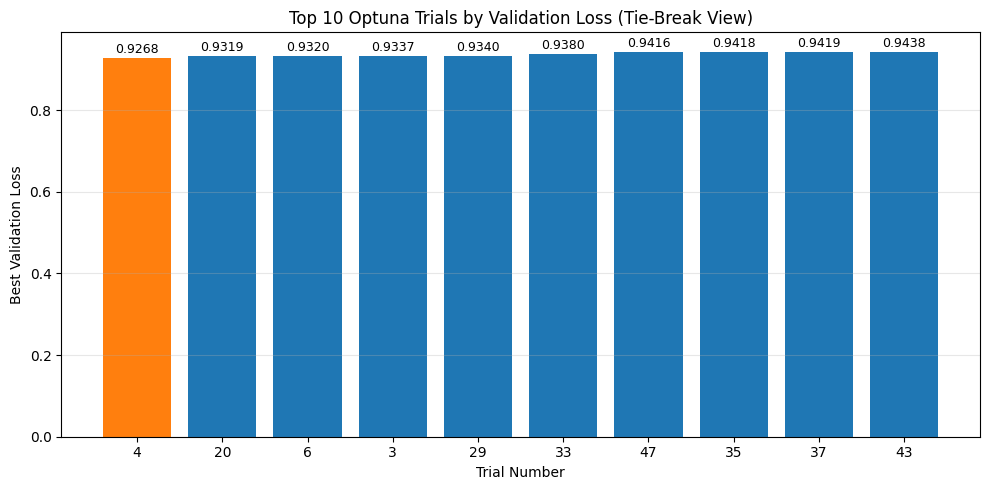

In [46]:
# Summarize all Optuna trials, apply the tie-break rule, and visualize the top-performing ones.
from IPython.display import display

# Build a clean table with one row per trial.
trial_rows = []
for trial in study.trials:
    trial_rows.append({
        "trial_number": trial.number,
        "state": trial.state.name,
        "val_macro_f1": trial.value if trial.value is not None else np.nan,
        "best_val_loss": trial.user_attrs.get("best_val_loss", np.nan),
        "hidden_dim": trial.params.get("hidden_dim"),
        "dropout": trial.params.get("dropout"),
        "lr": trial.params.get("lr"),
        "weight_decay": trial.params.get("weight_decay"),
        "noise_std": trial.params.get("noise_std"),
        "batch_size": trial.params.get("batch_size"),
    })

trials_df = pd.DataFrame(trial_rows).sort_values("trial_number").reset_index(drop=True)

print("All Optuna trials (50 rows expected):")
display(trials_df)

# Apply the model-selection rule: highest validation macro-F1, then lowest validation loss.
completed_trials_df = trials_df[trials_df["state"] == "COMPLETE"].copy()
ranked_trials_df = completed_trials_df.sort_values(
    ["val_macro_f1", "best_val_loss", "trial_number"],
    ascending=[False, True, True]
).reset_index(drop=True)

selected_trial_row = ranked_trials_df.iloc[0]
selected_trial_number = int(selected_trial_row["trial_number"])
selected_best_trial = study.trials[selected_trial_number]
selected_best_params = selected_best_trial.params

print("Selected best trial after applying tie-break rule:")
print(f"  trial_number   : #{selected_trial_number}")
print(f"  val_macro_f1   : {selected_trial_row['val_macro_f1']:.4f}")
print(f"  best_val_loss  : {selected_trial_row['best_val_loss']:.4f}")
print("  params:")
for k, v in selected_best_params.items():
    print(f"    {k:16s}: {v}")

top10_trials_df = ranked_trials_df.head(10).copy()
print("Top 10 completed trials ranked by validation macro-F1, then validation loss:")
display(top10_trials_df)

# Since the top trials may tie on macro-F1, plot validation loss to show the tie-break separation.
plt.figure(figsize=(10, 5))
bars = plt.bar(
    top10_trials_df["trial_number"].astype(str),
    top10_trials_df["best_val_loss"],
    color=["tab:orange" if t == selected_trial_number else "tab:blue" for t in top10_trials_df["trial_number"]]
)
plt.title("Top 10 Optuna Trials by Validation Loss (Tie-Break View)")
plt.xlabel("Trial Number")
plt.ylabel("Best Validation Loss")
plt.grid(axis="y", alpha=0.3)

for bar, score in zip(bars, top10_trials_df["best_val_loss"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{score:.4f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


## 10. Training Configuration

After Optuna finishes, pull out the best hyperparameters, rebuild the fusion model, and define the final training settings.


In [47]:
# Pull the final hyperparameters using the custom ranking rule:
# highest validation macro-F1, with lower validation loss as the tie-breaker.
_p = selected_best_params
MLP_HIDDEN             = _p["hidden_dim"]
DROPOUT                = _p["dropout"]
LEARNING_RATE          = _p["lr"]
WEIGHT_DECAY           = _p["weight_decay"]
AUGMENT_NOISE_STD      = _p["noise_std"]
PARTICIPANT_BATCH_SIZE = _p["batch_size"]

NUM_EPOCHS              = 500
EARLY_STOPPING_PATIENCE = 50
CHECKPOINT_FREQ         = 50
GRAD_CLIP_NORM          = 1.0

# Re-instantiate the fusion model with the selected hyperparameters.
mid_model = MidFusionClassifier(hidden_dim=MLP_HIDDEN, dropout=DROPOUT).to(DEVICE)
n_params  = sum(p.numel() for p in mid_model.parameters() if p.requires_grad)

n_dep_train  = sum(d["label"] for _, d in train_data)
n_ctrl_train = len(train_data) - n_dep_train
pos_weight   = torch.tensor(n_ctrl_train / n_dep_train, dtype=torch.float32, device=DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = Adam(mid_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

print("Training with selected Optuna hyperparameters:")
print(f"  selected_trial_number : #{selected_trial_number}")
print(f"  val_macro_f1          : {selected_trial_row['val_macro_f1']:.4f}")
print(f"  best_val_loss         : {selected_trial_row['best_val_loss']:.4f}")
for k, v in _p.items():
    print(f"  {k:20s}: {v}")
print(f"Trainable params  : {n_params:,}")
print(f"pos_weight        : {pos_weight.item():.4f}")
print(f"Batch size        : {PARTICIPANT_BATCH_SIZE}")
print(f"Epochs            : {NUM_EPOCHS}  (patience {EARLY_STOPPING_PATIENCE})")


Training with selected Optuna hyperparameters:
  selected_trial_number : #4
  val_macro_f1          : 0.7619
  best_val_loss         : 0.9268
  hidden_dim          : 128
  dropout             : 0.20492715994847455
  lr                  : 0.000579124212650602
  weight_decay        : 0.00011982192262672032
  noise_std           : 0.09582603411724216
  batch_size          : 16
Trainable params  : 33,025
pos_weight        : 2.5667
Batch size        : 16
Epochs            : 500  (patience 50)


## 11. Training Loop

- **Augmentation**: small Gaussian noise is added to both embeddings during training to regularize the MLP.
- **Early stopping**: training stops when validation macro-F1 stops improving.
- **Threshold tuning**: after training, the best classification threshold is selected on the validation set.


In [48]:
# Train the fusion MLP one epoch at a time and evaluate it on the validation split.
# The best checkpoint is tracked using validation macro-F1, then restored before threshold tuning.
def train_epoch():
    mid_model.train()
    idx     = torch.randperm(len(train_data)).tolist()
    batches = [idx[i : i + PARTICIPANT_BATCH_SIZE]
               for i in range(0, len(idx), PARTICIPANT_BATCH_SIZE)]
    total_loss, correct, n = 0.0, 0, len(train_data)

    for batch in batches:
        optimizer.zero_grad()
        for i in batch:
            _, data = train_data[i]
            text_emb  = torch.tensor(data["text_emb"],  dtype=torch.float32, device=DEVICE)
            audio_emb = torch.tensor(data["audio_emb"], dtype=torch.float32, device=DEVICE)
            # Gaussian noise augmentation on both embeddings
            text_emb  = text_emb  + torch.randn_like(text_emb)  * AUGMENT_NOISE_STD
            audio_emb = audio_emb + torch.randn_like(audio_emb) * AUGMENT_NOISE_STD
            label = torch.tensor(float(data["label"]), dtype=torch.float32, device=DEVICE)

            logit = mid_model(text_emb, audio_emb)
            loss  = criterion(logit, label) / len(batch)
            loss.backward()
            total_loss += loss.item() * len(batch)
            correct    += int((1 if torch.sigmoid(logit).item() >= 0.5 else 0) == data["label"])

        torch.nn.utils.clip_grad_norm_(mid_model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()
    return total_loss / n, correct / n


def evaluate(data: list, threshold: float = 0.5):
    mid_model.eval()
    total_loss, records = 0.0, []
    with torch.no_grad():
        for pid, d in data:
            text_emb  = torch.tensor(d["text_emb"],  dtype=torch.float32, device=DEVICE)
            audio_emb = torch.tensor(d["audio_emb"], dtype=torch.float32, device=DEVICE)
            label     = torch.tensor(float(d["label"]), dtype=torch.float32, device=DEVICE)
            logit     = mid_model(text_emb, audio_emb)
            total_loss += criterion(logit, label).item()
            prob = torch.sigmoid(logit).item()
            records.append((pid, 1 if prob >= threshold else 0, prob, d["label"]))
    df     = pd.DataFrame(records, columns=["pid", "pred", "prob", "label"])
    acc    = accuracy_score(df["label"], df["pred"])
    macro_f1 = f1_score(df["label"], df["pred"], average="macro", zero_division=0)
    return total_loss / len(data), acc, macro_f1, df


# ── Training ─────────────────────────────────────────────────────────────────
history = {"train_loss": [], "train_acc": [],
           "val_loss": [],   "val_acc": [],  "val_f1": []}
best_val_f1       = -1.0
epochs_no_improve = 0
best_ckpt         = None

print(f"{'Epoch':>6}  {'TrainLoss':>9}  {'TrainAcc':>8}  "
      f"{'ValLoss':>7}  {'ValAcc':>6}  {'ValF1':>7}")
print("-" * 58)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc         = train_epoch()
    val_loss, val_acc, val_f1, _  = evaluate(dev_data)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    if epoch % CHECKPOINT_FREQ == 0:
        torch.save({"epoch": epoch, "model_state_dict": mid_model.state_dict(),
                    "val_f1": val_f1},
                   SAVE_DIR / f"epoch{epoch}_mid_fusion.pth")

    if val_f1 > best_val_f1:
        best_val_f1       = val_f1
        epochs_no_improve = 0
        best_ckpt = {"epoch": epoch, "val_loss": val_loss,
                     "val_acc": val_acc, "val_f1": val_f1,
                     "state": {k: v.cpu().clone()
                               for k, v in mid_model.state_dict().items()}}
        torch.save(best_ckpt["state"], SAVE_DIR / "mid_fusion_best.pth")
        print(f"{epoch:6d}  {train_loss:9.4f}  {train_acc:8.4f}  "
              f"{val_loss:7.4f}  {val_acc:6.4f}  {val_f1:7.4f}  *** best")
    else:
        epochs_no_improve += 1
        if epoch % 10 == 0:
            print(f"{epoch:6d}  {train_loss:9.4f}  {train_acc:8.4f}  "
                  f"{val_loss:7.4f}  {val_acc:6.4f}  {val_f1:7.4f}")

    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nBest: epoch={best_ckpt['epoch']}  "
      f"val_loss={best_ckpt['val_loss']:.4f}  "
      f"val_f1={best_ckpt['val_f1']:.4f}")

# Restore best weights
mid_model.load_state_dict(best_ckpt["state"])
mid_model.to(DEVICE)

# Tune threshold on validation set
_, _, _, val_df = evaluate(dev_data)
best_thresh, best_f1 = 0.5, -1.0
for t in np.arange(0.10, 0.91, 0.05):
    f1 = f1_score(val_df["label"], (val_df["prob"] >= t).astype(int),
                  average="macro", zero_division=0)
    if f1 > best_f1:
        best_f1, best_thresh = f1, float(t)
print(f"Best threshold: {best_thresh:.2f}  (val macro-F1 = {best_f1:.4f})")

 Epoch  TrainLoss  TrainAcc  ValLoss  ValAcc    ValF1
----------------------------------------------------------
     1     0.9519    0.7944   1.0232  0.7429   0.6749  *** best
     3     0.7197    0.9019   0.9634  0.7714   0.7200  *** best
     6     0.4529    0.8738   1.1607  0.7714   0.7348  *** best
    10     0.3714    0.9065   1.5875  0.7429   0.6749
    20     0.3832    0.9393   1.6175  0.6571   0.6023
    30     0.2783    0.9346   1.8594  0.6857   0.6259
    40     0.2889    0.9439   2.0236  0.7143   0.6500
    50     0.2318    0.9486   1.7323  0.6857   0.6259

Early stopping at epoch 56.

Best: epoch=6  val_loss=1.1607  val_f1=0.7348
Best threshold: 0.50  (val macro-F1 = 0.7348)


## 12. Training Curves

Plot the training and validation metrics to inspect optimization behavior and check for overfitting.


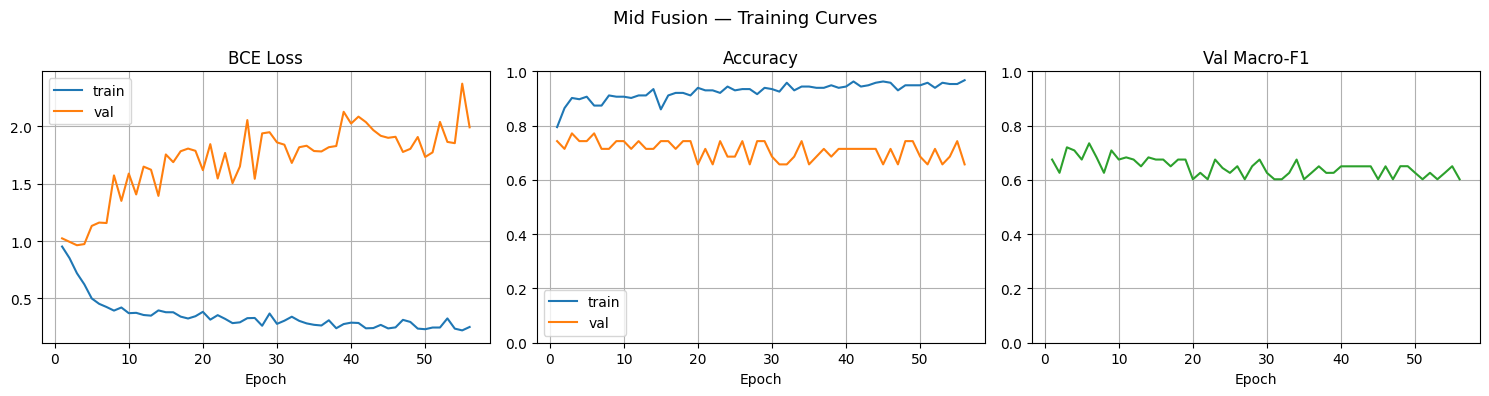

In [49]:
epochs_ran = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_ran, history["train_loss"], label="train", color="tab:blue")
axes[0].plot(epochs_ran, history["val_loss"],   label="val",   color="tab:orange")
axes[0].set_title("BCE Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_ran, history["train_acc"], label="train", color="tab:blue")
axes[1].plot(epochs_ran, history["val_acc"],   label="val",   color="tab:orange")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True)

axes[2].plot(epochs_ran, history["val_f1"], color="tab:green")
axes[2].set_title("Val Macro-F1")
axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1)
axes[2].grid(True)

plt.suptitle("Mid Fusion — Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

## 13. Test Set Evaluation

Evaluate the best saved fusion checkpoint on the held-out test set using the threshold tuned on the validation split.


In [50]:
_, _, _, test_df = evaluate(test_data, threshold=best_thresh)

y_true = test_df["label"].values.astype(int)
y_pred = test_df["pred"].values.astype(int)

print(f"Best checkpoint : epoch {best_ckpt['epoch']}  "
      f"val_loss={best_ckpt['val_loss']:.4f}  val_f1={best_ckpt['val_f1']:.4f}")
print(f"Decision threshold : {best_thresh:.2f}  (tuned on validation macro-F1)")
print(f"Participants : {len(test_df)}\n")
print(classification_report(y_true, y_pred,
                             target_names=["Control", "Depressed"], zero_division=0))

Best checkpoint : epoch 6  val_loss=1.1607  val_f1=0.7348
Decision threshold : 0.50  (tuned on validation macro-F1)
Participants : 47

              precision    recall  f1-score   support

     Control       0.93      0.79      0.85        33
   Depressed       0.63      0.86      0.73        14

    accuracy                           0.81        47
   macro avg       0.78      0.82      0.79        47
weighted avg       0.84      0.81      0.82        47



## 14. Confusion Matrix

Visualize the final test-set prediction counts for each class.


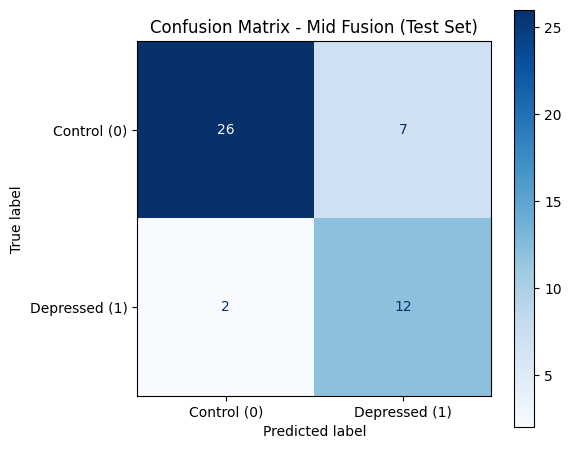

In [51]:
# Build and display the confusion matrix for the final test predictions.
# The extra lines seen previously were Matplotlib grid lines from the active plotting style.
# Disable the grid explicitly so each confusion-matrix cell renders cleanly.
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Control (0)", "Depressed (1)"]
)
disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")

# Turn off grid lines that can visually cut across the heatmap cells.
ax.grid(False)
plt.grid(False)

# Keep the image crisp and the layout tidy.
ax.set_title("Confusion Matrix - Mid Fusion (Test Set)")
fig.tight_layout()
plt.show()